In [21]:
!pip install arabic_reshaper

In [22]:
!pip install python_bidi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 15.4 MB/s eta 0:00:00


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
import zipfile
import pandas as pd
import os

folder = '/content/drive/MyDrive/TransformesCod/03-restaurant/Find_meals/'

data_path = '/content/drive/MyDrive/TransformesCod/03-restaurant/Find_meals/indian_food[1].zip'

with zipfile.ZipFile(data_path, 'r') as zip_ref:
    zip_ref.extractall(folder)
data_csv = os.path.join(folder, 'indian_food.csv')
df = pd.read_csv(data_csv)
df.head(3)

,name,ARname,ingredients,ARingredients,diet,ARdiet,prep_time,cook_time,flavor_profile,course,ARflavor_profile,ARcourse,state,region
0,Balu shahi,بالو شاهي,"Maida flour, yogurt, oil, sugar",دقيق مائدة، زبادي، زيت، سكر,vegetarian,نباتي,45,25,sweet,dessert,حلو,تحلية,West Bengal,East
1,Boondi,بوندي,"Gram flour, ghee, sugar",جرام دقيق، سمن، سكر,vegetarian,نباتي,80,30,sweet,dessert,حلو,تحلية,Rajasthan,West
2,Gajar ka halwa,جاجار كا حلوة,"Carrots, milk, sugar, ghee, cashews, raisins",جزر، حليب، سكر، سمن، كاجو، زبيب,vegetarian,نباتي,15,60,sweet,dessert,حلو,تحلية,Punjab,North


In [4]:
import numpy as np
similarities_path = folder + 'cosine_similarity_matrix.npy'
similarities = np.load(similarities_path)
print(similarities)
print(similarities.shape)


[[1.0000001  0.6945308  0.61966586 ... 0.3559543  0.24791378 0.23562291]
 [0.6945308  1.         0.68130034 ... 0.4211163  0.3362406  0.24663337]
 [0.61966586 0.68130034 1.         ... 0.442216   0.42944115 0.32536662]
 ...
 [0.3559543  0.4211163  0.442216   ... 1.0000001  0.539516   0.35049137]
 [0.24791378 0.3362406  0.42944115 ... 0.539516   1.         0.41640878]
 [0.23562291 0.24663337 0.32536662 ... 0.35049137 0.41640878 1.        ]]
(255, 255)


In [11]:
re_name = 'بوندي'
s =df[df['ARname'] == re_name].index[0]
print(s)

index = 1
s =df.iloc[index]['ARname']
print(s)

1
بوندي


In [34]:
def get_index(re_name):
  return df[df['ARname'] == re_name].index[0]

def get_re_name(index):
  return df.iloc[index]['ARname']

def get_recipe_recommendations(re_name):
  index = get_index(re_name)
  sims = similarities[index]
  scorce = list(enumerate(sims))
  sort_scorce = sorted(scorce, key=lambda x: x[1], reverse=True)
  return sort_scorce

re_name = 'بوندي'
sort_scorce = get_recipe_recommendations(re_name)
for re in sort_scorce[:8]:
  index=re[0]
  scorce = re[1]
  re = get_re_name(index)
  print(f'name: :{re}  ,  scorce: {scorce}')

name: :بوندي  ,  scorce: 1.0
name: :لادو  ,  scorce: 1.0
name: :شانكاربالي  ,  scorce: 0.923434853553772
name: :ميهيدانا  ,  scorce: 0.920032262802124
name: :إيمارتي  ,  scorce: 0.8726876974105835
name: :سوتار فيني  ,  scorce: 0.8697835206985474
name: :قباني كا ميتا  ,  scorce: 0.8641942739486694
name: :مهيم حلوة  ,  scorce: 0.8603127598762512


In [36]:
def get_recipe_recommendations_from_previous_orders(previous_orders):
  indices = [get_index(re_name) for re_name in previous_orders]
  sims = similarities[indices].mean(axis=0)
  scorce = list(enumerate(sims))
  sort_scorce = sorted(scorce, key=lambda x: x[1], reverse=True)
  return sort_scorce

previous_orders =['جلاب بقر', 'جاليبي']
scorce = get_recipe_recommendations_from_previous_orders(previous_orders)

top_recommendations = scorce[:10]
top_indices = [rec[0] for rec in top_recommendations]
top_scores = [rec[1] for rec in top_recommendations]
top_names = [get_re_name(idx) for idx in top_indices]
for i in range(10):
  print(top_names[i])

جلاب بقر
جاليبي
بايوخ
غيفار
شاهي توكرا
سوهان بابدي
الله بابدي
رابري
توريا باترا فاتانا سابجي
بندر لادو


/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 65010 (\N{ARABIC LIGATURE ALLAH ISOLATED FORM}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65010 (\N{ARABIC LIGATURE ALLAH ISOLATED FORM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


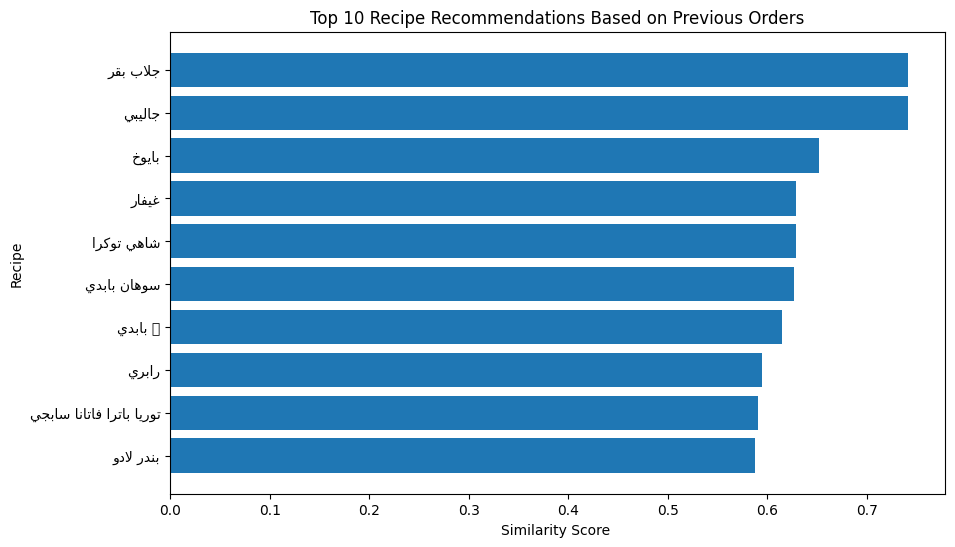

In [42]:
import matplotlib.pyplot as plt
import arabic_reshaper as ar
from bidi.algorithm import get_display

top_names_display = [get_display(ar.reshape(names)) for names in top_names]
top_df = pd.DataFrame({'names1': top_names_display, 'scorce1': top_scores})

plt.figure(figsize=(10, 6))
plt.barh(top_df['names1'], top_df['scorce1'])

plt.xlabel( 'Similarity Score ' )
plt.ylabel( 'Recipe')
plt.title( 'Top 10 Recipe Recommendations Based on Previous Orders' )

plt.gca().invert_yaxis()
